Лабораторная работа №3 (Измерение альфа и бета сигналов)

Касьяненко Вера и Кремпольская Екатерина

P3420

Импорт необходимых библиотек:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, welch, iirnotch, detrend

try:
    from IPython.display import display
except Exception:
    display = print

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

Загрузка наших изменений.



1. Спокойное состояние
2. Закрытые глаза
3. Глаза открыты, спокойная музыка
4. Глаза открыты, решение задач
5. Глаза открыты, игра в Dota 2



In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1q-nXHu5lW9ABsGdGhvSKB1rKTlaSeCnc' -O 1.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1-_M13BXWjRk8ZYDEUY7BYnkDfTksE2Sf' -O 2.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1BDMsUS0_q2cqt2mgATr8Rh1Rf5dV1GTO' -O 3.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1ZvOUlManCeSwKTMb5e6bMQcCdUw1tdjD' -O 4.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1AfjfBf_yyondCzEboCQ7duTQvYT4t8AB' -O 5.csv

In [15]:
files = {
    "Спокойное состояние": "1.csv",
    "Закрытые глаза": "2.csv",
    "Закрытые глаза + спокойная музыка": "3.csv",
    "Открытые глаза + решение задач": "4.csv",
    "Игра": "5.csv",
}

channels = ["A0 (В)", "A2 (В)"]

## Загрузка CSV и оценка fs

- удаляем пустые значения,
- чистим одинаковые моменты времени,
- время делаем от нуля


In [11]:
def load_eeg_any_csv(path: str, channels: list[str]) -> tuple[np.ndarray, dict[str, np.ndarray], float]:
    df = pd.read_csv(path)

    time_candidates = ["Время (с)", "Время", "time", "Time", "t", "timestamp"]
    t_col = next((c for c in time_candidates if c in df.columns), None)

    needed = [t_col] + channels
    missing = [c for c in needed if c not in df.columns]

    # убираем NaN
    df = df[needed].dropna()

    # приводим к float
    df[t_col] = df[t_col].astype(float)
    for ch in channels:
        df[ch] = df[ch].astype(float)

    # если одинаковые времена встречаются несколько раз - усредняем
    df = (
        df.groupby(t_col, as_index=False)[channels]
          .mean()
          .sort_values(t_col)
          .reset_index(drop=True)
    )

    t = df[t_col].to_numpy()

    # время от 0
    t = t - t[0]

    # оценка fs
    dt = np.diff(t)
    dt = dt[dt > 0]
    fs = float(1.0 / np.median(dt)) if len(dt) else 0.0

    X = {ch: df[ch].to_numpy() for ch in channels}
    return t, X, fs

## Предобработка

1) убираем постоянное смещение,
2) оставляем полосу 1-40 Гц,
3) если можно - вырезаем 50 Гц


In [5]:
def bandpass(x: np.ndarray, fs: float, lo: float, hi: float, order: int = 4) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs
    hi = min(hi, nyq * 0.99)
    b, a = butter(order, [lo / nyq, hi / nyq], btype="band")
    return filtfilt(b, a, x)

def notch_if_possible(x: np.ndarray, fs: float, f0: float = 50.0, q: float = 30.0) -> np.ndarray:
    nyq = 0.5 * fs
    if f0 >= nyq * 0.99:
        return x
    w0 = f0 / nyq
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, x)

def preprocess_eeg(x: np.ndarray, fs: float) -> np.ndarray:
    x0 = detrend(np.asarray(x, dtype=float), type="constant")
    y = bandpass(x0, fs, 1.0, 40.0, order=4)
    y = notch_if_possible(y, fs, f0=50.0, q=30.0)
    return y

## Относительная мощность в диапазоне (через Welch)

Считаем спектр (Welch), затем:
- мощность в нужной полосе (альфа или бета),
- мощность в общей полосе 1-40 Гц,
- относительная мощность = (мощность полосы) / (общая мощность)


In [6]:
def integrate_psd(f: np.ndarray, pxx: np.ndarray, f_lo: float, f_hi: float) -> float:
    m = (f >= f_lo) & (f <= f_hi)
    if not np.any(m):
        return 0.0
    return float(np.trapezoid(pxx[m], f[m]))

def band_power_relative(
    x_filtered: np.ndarray,
    fs: float,
    band: tuple[float, float],
    total_band: tuple[float, float] = (1.0, 40.0),
    nperseg: int = 1024
) -> tuple[np.ndarray, np.ndarray, float, float]:
    nperseg = int(min(nperseg, len(x_filtered)))

    f, pxx = welch(x_filtered, fs=fs, nperseg=nperseg)

    bpow = integrate_psd(f, pxx, band[0], band[1])
    t_hi = min(total_band[1], float(np.max(f)))
    tpow = integrate_psd(f, pxx, total_band[0], t_hi)

    rel = (bpow / tpow) if tpow > 0 else 0.0
    return f, pxx, float(bpow), float(rel)

## Основной прогон по всем состояниям


In [18]:
ALPHA = (8.0, 13.0)
BETA  = (13.0, 30.0)

results: dict[str, dict[str, dict]] = {}

for condition, fp in files.items():
    t, X_raw, fs = load_eeg_any_csv(fp, channels)

    results[condition] = {}
    for ch in channels:
        x_raw = X_raw[ch]
        x_f = preprocess_eeg(x_raw, fs)

        f_a, psd_a, a_pow, a_rel = band_power_relative(x_f, fs, ALPHA)
        f_b, psd_b, b_pow, b_rel = band_power_relative(x_f, fs, BETA)

        results[condition][ch] = {
            "t": t,
            "raw": x_raw,
            "signal_filtered": x_f,
            "fs": fs,
            "alpha_power": a_pow,
            "alpha_relative": a_rel,
            "beta_power": b_pow,
            "beta_relative": b_rel,
            "freqs": f_a,
            "psd": psd_a,
        }

    msg = " | ".join([f"{ch}: alpha={results[condition][ch]['alpha_relative']:.4f}, beta={results[condition][ch]['beta_relative']:.4f}"
                      for ch in channels])
    print(f"{condition}: {msg}")

Спокойное состояние: A0 (В): alpha=0.0605, beta=0.0416 | A2 (В): alpha=0.0721, beta=0.0320
Закрытые глаза: A0 (В): alpha=0.0838, beta=0.0527 | A2 (В): alpha=0.1189, beta=0.0434
Закрытые глаза + спокойная музыка: A0 (В): alpha=0.0766, beta=0.0509 | A2 (В): alpha=0.1114, beta=0.0411
Открытые глаза + решение задач: A0 (В): alpha=0.0773, beta=0.0615 | A2 (В): alpha=0.0698, beta=0.0531
Игра: A0 (В): alpha=0.0469, beta=0.0712 | A2 (В): alpha=0.0584, beta=0.0593


## Сравнительные графики

Строим:
- относительную альфу,
- относительную бету,
- альфа/бета,
- PSD на одном графике (по альфа)


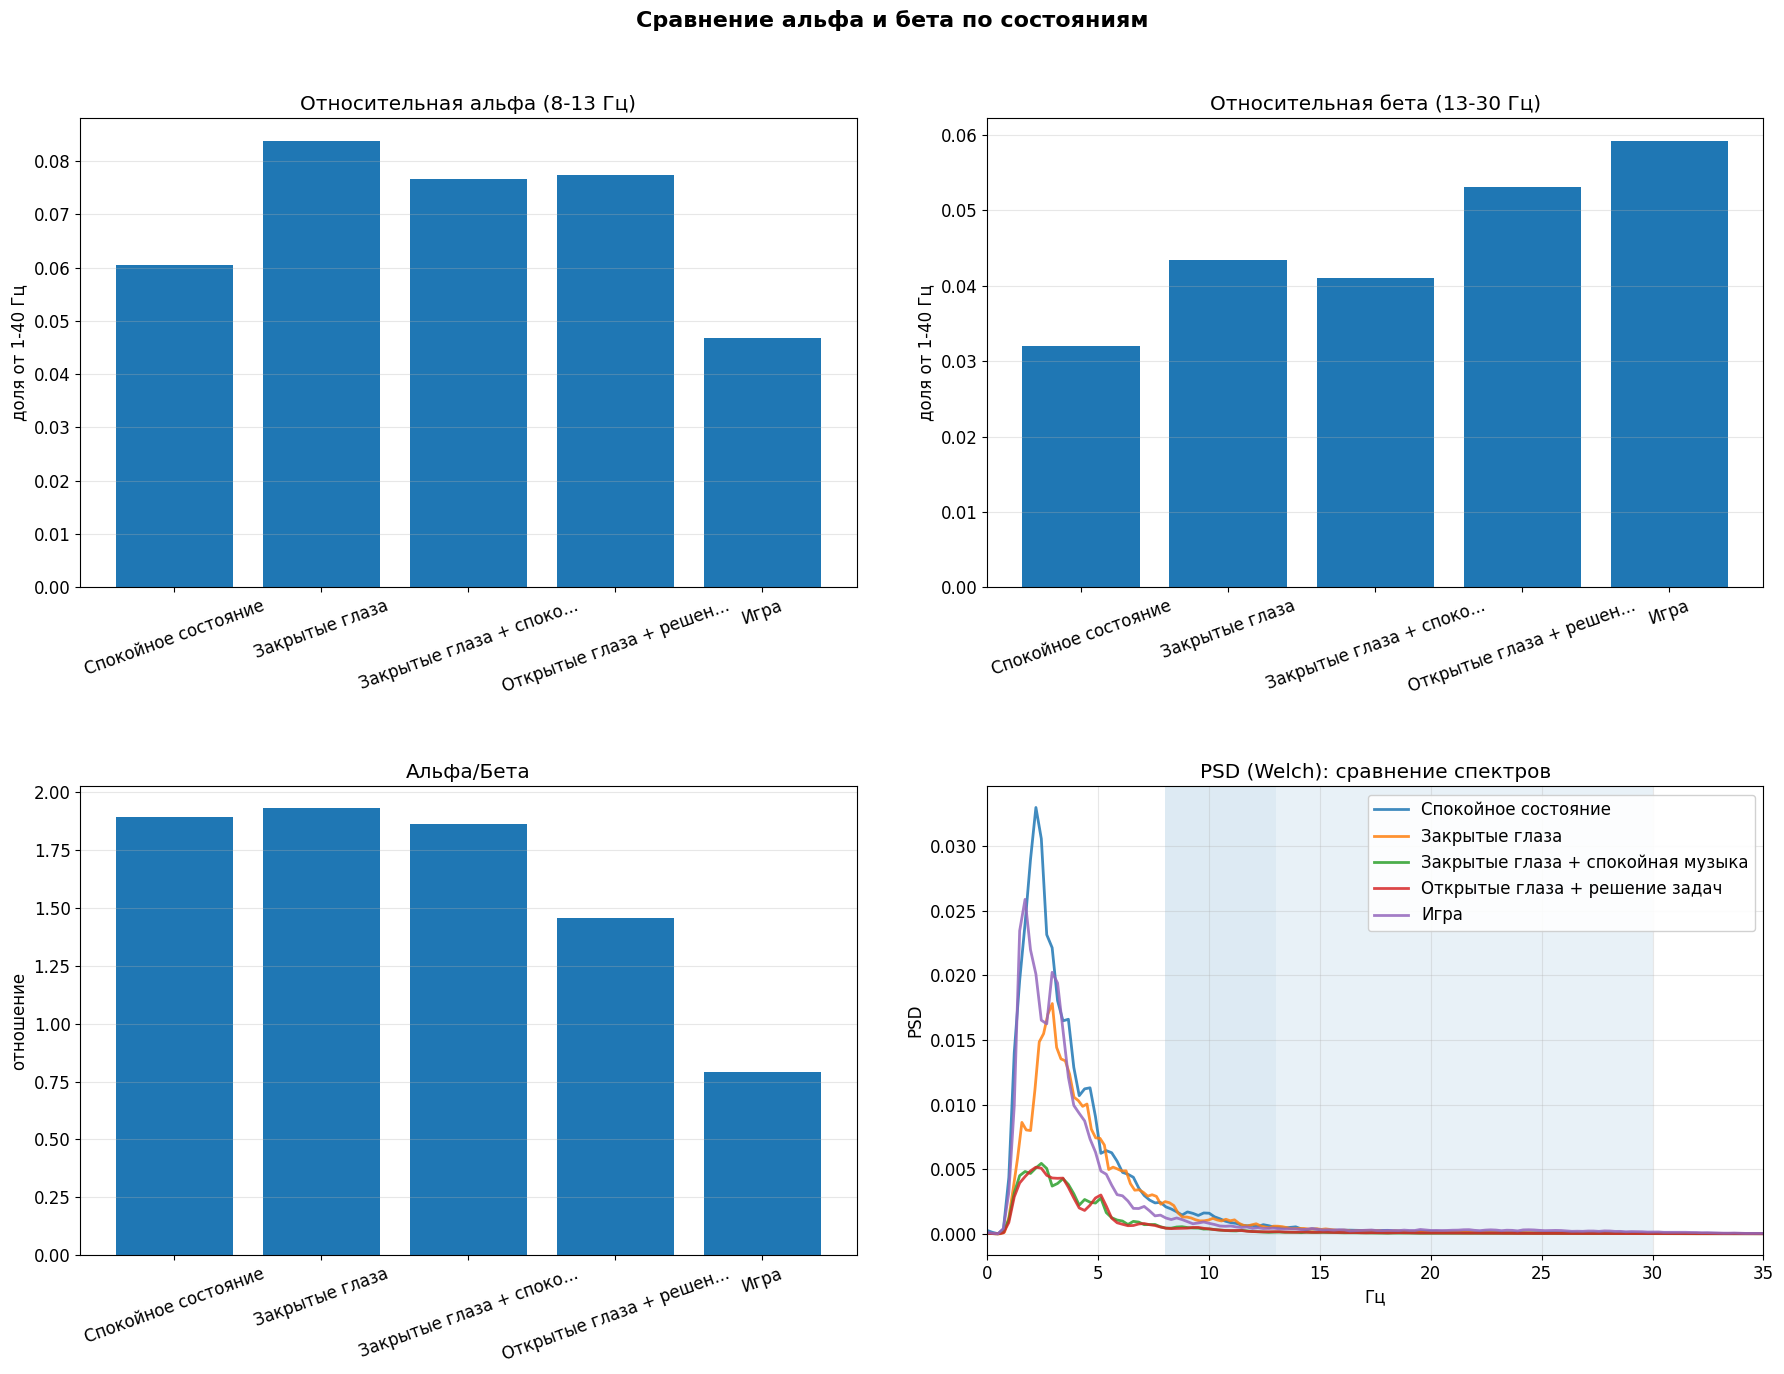

In [ ]:
def short_label(s: str, max_len: int = 22) -> str:
    return s if len(s) <= max_len else (s[:max_len] + "...")

if results:
    conditions = list(results.keys())
    xlabels = [short_label(c) for c in conditions]

    alpha_vals = [results[c]["alpha_relative"] for c in conditions]
    beta_vals  = [results[c]["beta_relative"]  for c in conditions]
    ratio_vals = [
        (results[c]["alpha_relative"] / results[c]["beta_relative"])
        if results[c]["beta_relative"] > 0 else 0.0
        for c in conditions
    ]

    fig, ax = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle("Сравнение альфа и бета по состояниям", fontsize=16, fontweight="bold")

    ax[0, 0].bar(xlabels, alpha_vals)
    ax[0, 0].set_title("Относительная альфа (8-13 Гц)")
    ax[0, 0].set_ylabel("доля от 1-40 Гц")
    ax[0, 0].grid(True, axis="y", alpha=0.3)
    ax[0, 0].tick_params(axis="x", rotation=20)

    ax[0, 1].bar(xlabels, beta_vals)
    ax[0, 1].set_title("Относительная бета (13-30 Гц)")
    ax[0, 1].set_ylabel("доля от 1-40 Гц")
    ax[0, 1].grid(True, axis="y", alpha=0.3)
    ax[0, 1].tick_params(axis="x", rotation=20)

    ax[1, 0].bar(xlabels, ratio_vals)
    ax[1, 0].set_title("Альфа/Бета")
    ax[1, 0].set_ylabel("отношение")
    ax[1, 0].grid(True, axis="y", alpha=0.3)
    ax[1, 0].tick_params(axis="x", rotation=20)

    ax[1, 1].set_title("PSD (Welch): сравнение спектров")
    ax[1, 1].set_xlabel("Гц")
    ax[1, 1].set_ylabel("PSD")
    for c in conditions:
        d = results[c]
        ax[1, 1].plot(d["freqs"], d["psd"], label=c, alpha=0.85, linewidth=2)
    ax[1, 1].axvspan(8, 13, alpha=0.15)
    ax[1, 1].axvspan(13, 30, alpha=0.10)
    ax[1, 1].set_xlim(0, 35)
    ax[1, 1].grid(True, alpha=0.3)
    ax[1, 1].legend(loc="best", framealpha=0.9)

    plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=4.0, w_pad=3.0)
    plt.show()


## Детальный график для каждого состояния

Для каждого состояния:
- фильтрованный сигнал,
- PSD (0-40 Гц),
- печатаем три числа: альфа, бета, альфа/бета.


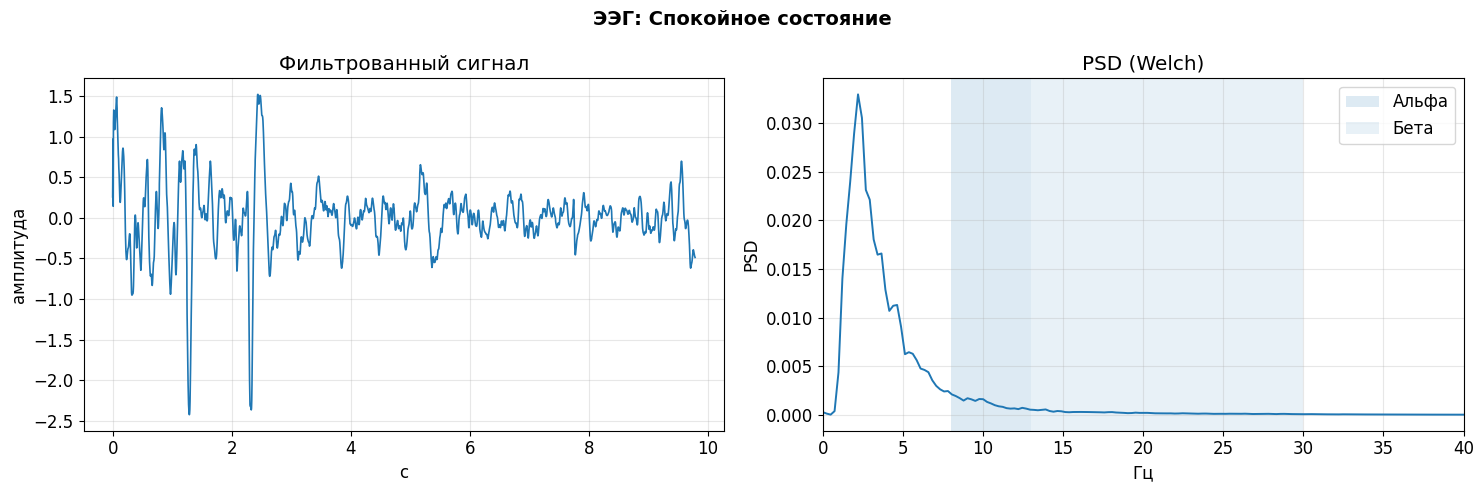

Альфа (относительная): 0.0605
Бета  (относительная): 0.0320
Альфа/Бета:           1.89


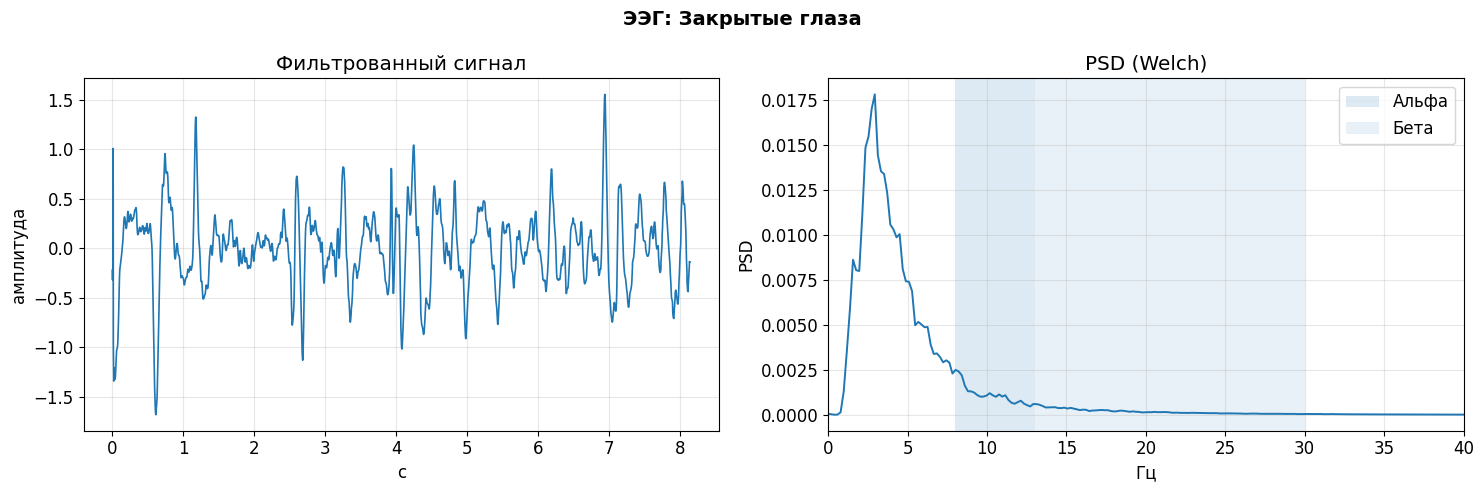

Альфа (относительная): 0.0838
Бета  (относительная): 0.0434
Альфа/Бета:           1.93


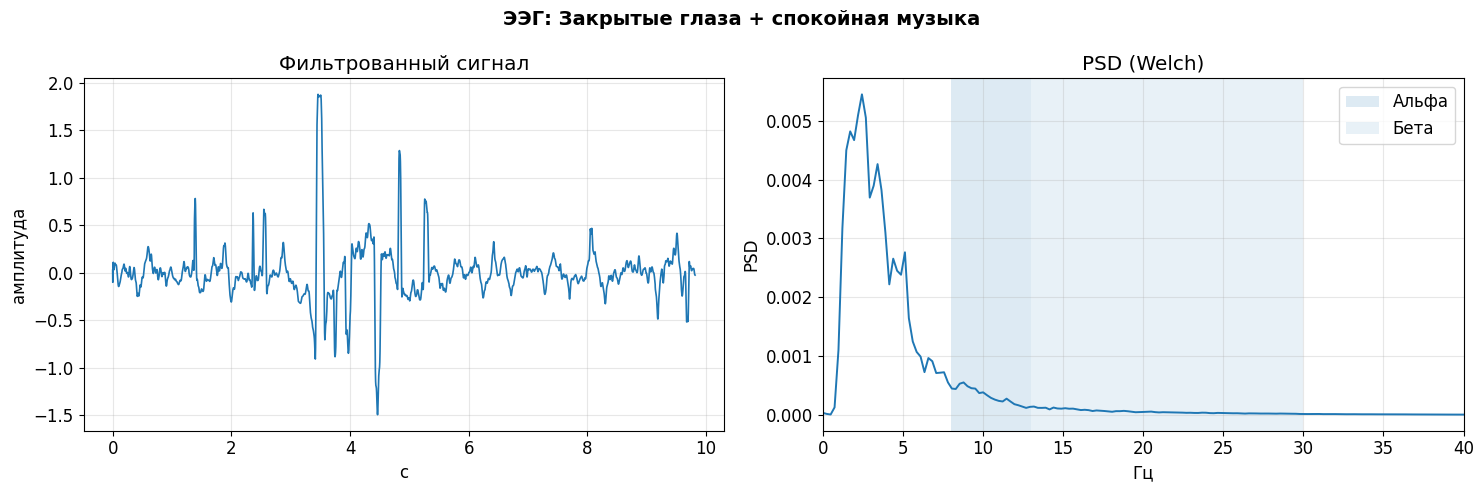

Альфа (относительная): 0.0766
Бета  (относительная): 0.0411
Альфа/Бета:           1.86


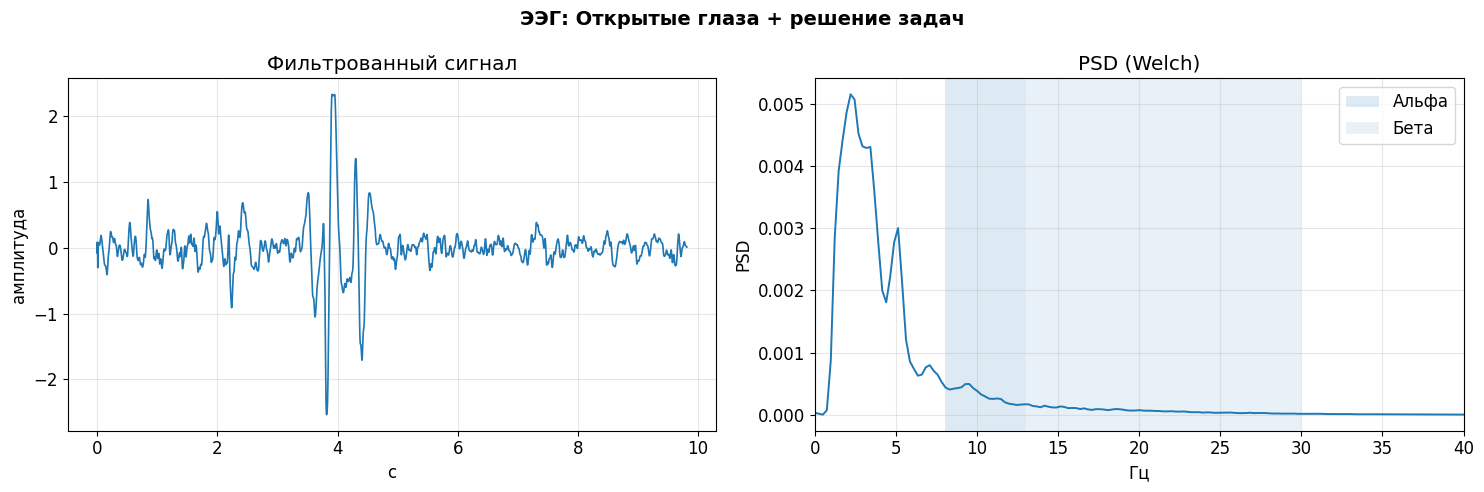

Альфа (относительная): 0.0773
Бета  (относительная): 0.0531
Альфа/Бета:           1.46


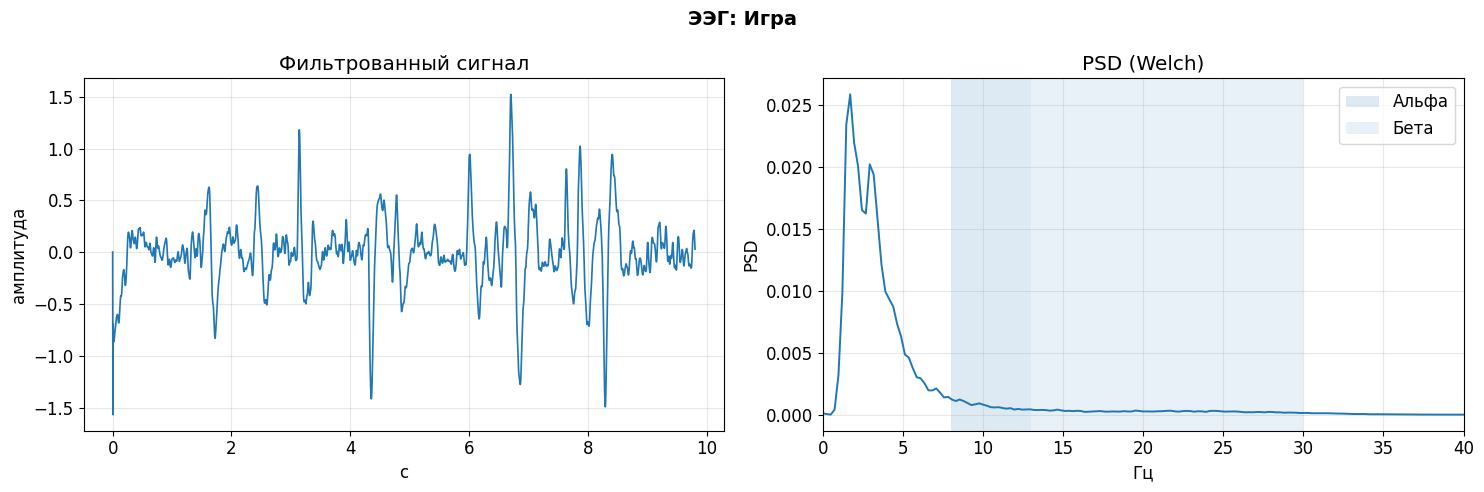

Альфа (относительная): 0.0469
Бета  (относительная): 0.0593
Альфа/Бета:           0.79


In [ ]:
if results:
    for condition, data in results.items():
        fs = data["fs"]
        t = data["t"]
        x = data["signal_filtered"]

        n10 = int(min(len(x), fs * 10))
        t_short = t[:n10]
        x_short = x[:n10]

        f, pxx = welch(x, fs=fs, nperseg=int(min(1024, len(x))))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f"ЭЭГ: {condition}", fontsize=14, fontweight="bold")

        ax1.plot(t_short, x_short, linewidth=1.2)
        ax1.set_title("Фильтрованный сигнал")
        ax1.set_xlabel("с")
        ax1.set_ylabel("амплитуда")
        ax1.grid(True, alpha=0.3)

        ax2.plot(f, pxx, linewidth=1.4)
        ax2.set_title("PSD (Welch)")
        ax2.set_xlabel("Гц")
        ax2.set_ylabel("PSD")
        ax2.set_xlim(0, 40)
        ax2.axvspan(8, 13, alpha=0.15, label="Альфа")
        ax2.axvspan(13, 30, alpha=0.10, label="Бета")
        ax2.grid(True, alpha=0.3)
        ax2.legend()

        plt.tight_layout()
        plt.show()

        a = data["alpha_relative"]
        b = data["beta_relative"]
        r = (a / b) if b > 0 else 0.0
        print(f"Альфа (относительная): {a:.4f}")
        print(f"Бета  (относительная): {b:.4f}")
        print(f"Альфа/Бета:           {r:.2f}")


## Итоговая таблица и выводы


In [ ]:
if results:
    rows = []
    for condition, d in results.items():
        a = d["alpha_relative"]
        b = d["beta_relative"]
        rows.append({
            "Состояние": condition,
            "Альфа (отн.)": a,
            "Бета (отн.)": b,
            "Альфа/Бета": (a / b) if b > 0 else 0.0
        })

    df_results = pd.DataFrame(rows)

    df_alpha_sorted = df_results.sort_values("Альфа (отн.)", ascending=False).reset_index(drop=True)

    df_show = df_alpha_sorted.copy()
    df_show["Альфа (отн.)"] = df_show["Альфа (отн.)"].map(lambda x: f"{x:.4f}")
    df_show["Бета (отн.)"]  = df_show["Бета (отн.)"].map(lambda x: f"{x:.4f}")
    df_show["Альфа/Бета"]   = df_show["Альфа/Бета"].map(lambda x: f"{x:.2f}")

    display(
        df_show.style
        .set_caption("Сравнение альфа и бета по состояниям")
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold"), ("text-align", "center")]},
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]}
        ])
    )

    max_alpha_row = df_alpha_sorted.iloc[0]
    min_alpha_row = df_alpha_sorted.iloc[-1]
    max_beta_row = df_results.loc[df_results["Бета (отн.)"].idxmax()]

    print(f"Наибольшая альфа: '{max_alpha_row['Состояние']}' ({max_alpha_row['Альфа (отн.)']:.4f})")
    print(f"Наименьшая альфа: '{min_alpha_row['Состояние']}' ({min_alpha_row['Альфа (отн.)']:.4f})")
    print(f"Наибольшая бета:  '{max_beta_row['Состояние']}' ({max_beta_row['Бета (отн.)']:.4f})")


,Состояние,Альфа (отн.),Бета (отн.),Альфа/Бета
0,Закрытые глаза,0.0838,0.0434,1.93
1,Открытые глаза + решение задач,0.0773,0.0531,1.46
2,Закрытые глаза + спокойная музыка,0.0766,0.0411,1.86
3,Спокойное состояние,0.0605,0.0320,1.89
4,Игра,0.0469,0.0593,0.79


Наибольшая альфа: 'Закрытые глаза' (0.0838)
Наименьшая альфа: 'Игра' (0.0469)
Наибольшая бета:  'Игра' (0.0593)


## Выводы

### Альфа-ритм (8-13 Гц)
- Максимальная альфа: "Закрытые глаза" - 0.0838, это ожидаемо: без зрительной нагрузки мозг чаще "уходит" в более спокойный режим.
- Минимальная альфа: "Игра" - 0.0469, во время игры внимание и вовлеченность выше, поэтому альфа обычно падает.

Итог по альфе (от большего к меньшему):
1) Закрытые глаза (0.0838)  
2) Открытые глаза + решение задач (0.0773)  
3) Закрытые глаза + спокойная музыка (0.0766)  
4) Спокойное состояние (0.0605)  
5) Игра (0.0469)

### Бета-ритм (13-30 Гц)
- Максимальная бета: "Игра" - 0.0593: игра = постоянное внимание, реакция, контроль.
- Второе место: "Открытые глаза + решение задач" - 0.0531: задачи требуют концентрации.
- Самая низкая бета: "Спокойное состояние" - 0.0320.

Итог по бете (от большего к меньшему):
1) Игра (0.0593)  
2) Открытые глаза + решение задач (0.0531)  
3) Закрытые глаза (0.0434)  
4) Закрытые глаза + спокойная музыка (0.0411)  
5) Спокойное состояние (0.0320)

### Соотношение Альфа/Бета
- Самое высокое Альфа/Бета: "Закрытые глаза" - 1.93, это означает "альфы заметно больше, чем беты", то есть более спокойное состояние.
- Самое низкое Альфа/Бета: "Игра" - 0.79, это означает "беты больше, чем альфы" - активная нагрузка и внимание.

В целом хорошо сходится с теорией. Самое "спокойное" по показателям: Закрытые глаза (альфа максимум, альфа/бета максимум). Самое "активное": Игра (бета максимум, альфа минимум, альфа/бета минимум). Задачи с открытыми глазами ожидаемо дают рост беты по сравнению со спокойным режимом.
